In [1]:
import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE
import os

from sklearn.cluster import KMeans
from itertools import combinations
import pickle

# Clustering sanity check — concavity_w5000 (7 mice, 3 seeds)

Copy of `clustering_analysis_baseline_no_dec_sanity_check_short.ipynb`, adjusted to use
`concavity_reg_weight=5000` checkpoints (`../training/runs/concavity_w5000_seed{42,101,569}`)
instead of the `baseline_no_dec_11mice` runs.

Differences from the baseline notebook:
- Only 3 cross-seed checkpoints exist for this run (`42`, `101`, `569`), not 5 — all seed
  loops/combinations below use 3, not 5.
- These runs use the 7 `sensorium_original` mice (all GrayImageNet, single data path), not the
  baseline's 11-mice set — the per-animal path lookup is simplified accordingly.

In [2]:
def whiten_readouts(cov_ema, readouts, eps=1e-5):
    eye = torch.eye(cov_ema.shape[0], dtype=cov_ema.dtype, device='cpu')
    L = torch.linalg.cholesky(cov_ema + eps * eye)

    whitened_readouts = L.T @ readouts.T
    return whitened_readouts.T

In [3]:
!ls ../training/runs


baseline_seed42		 concavity_w8000_seed42     peak_distance_w40_seed42
concavity_w1000_seed42	 peak_distance_w100_seed42  peak_distance_w50_seed42
concavity_w2000_seed42	 peak_distance_w10_seed42   peak_distance_w5_seed101
concavity_w3000_seed42	 peak_distance_w200_seed42  peak_distance_w5_seed42
concavity_w5000_seed101  peak_distance_w20_seed42   peak_distance_w5_seed569
concavity_w5000_seed42	 peak_distance_w300_seed42
concavity_w5000_seed569  peak_distance_w30_seed42


In [4]:
example = torch.load(
    '../training/runs/concavity_w5000_seed42/model_weights.pth',
      map_location=torch.device('cpu'))

animals = list(set(
    [i.split('.')[1] for i in list(example.keys()) if 'readout' in i]
))

animals


['21067-10-18',
 '23964-4-22',
 '26872-17-20',
 '22846-10-16',
 '27204-5-13',
 '23343-5-17',
 '23656-14-22']

In [5]:
len(animals)

7

In [6]:
# '26872-17-20'
animals = [
    '21067-10-18',
    '23964-4-22',
    # '26872-17-20',
    '22846-10-16',
    '27204-5-13',
    '23343-5-17',
    '23656-14-22'
    ]

In [7]:
models = {}

for s in [42, 101, 569]:
    path = f'../training/runs/concavity_w5000_seed{s}/model_weights.pth'
    seed_w = torch.load(path, map_location=torch.device('cpu'))
    models[s] = {}
    for a in animals:
        models[s][a] = seed_w[f'readout.{a}._features'].squeeze().numpy()
    models[s]['mu_ema'] = seed_w['whitener.mu_ema'].numpy()
    models[s]['cov_ema'] = seed_w['whitener.cov_ema'].numpy()


In [8]:
whitened = []
for s in models.keys():
    rr = torch.from_numpy(
        np.vstack([models[s][a] for a in animals])
    )
    rr_w = whiten_readouts(torch.from_numpy(models[s]['cov_ema']), rr)
    whitened.append(rr_w.numpy())

In [9]:
len(whitened), whitened[0].shape

(3, (46793, 96))

### Clean data - only based on data

In [10]:
path_dict = {}
path_link = {}
for a in animals:
    # concavity_w5000 was trained on the 7 sensorium_original mice, all GrayImageNet, single basepath
    path_dict[a] = '/user/turishcheva/nathans_code/sensorium_original/'
    path_link[a] = '-GrayImageNet-'


In [11]:
path_link

{'21067-10-18': '-GrayImageNet-',
 '23964-4-22': '-GrayImageNet-',
 '22846-10-16': '-GrayImageNet-',
 '27204-5-13': '-GrayImageNet-',
 '23343-5-17': '-GrayImageNet-',
 '23656-14-22': '-GrayImageNet-'}

In [12]:
# mice = os.listdir(data_path)
coords = {}
coords_list = []
for a in animals:
    load_coords = np.load(
        f'{path_dict[a]}static{a}{path_link[a]}94c6ff995dac583098847cfecd43e7b6/meta/neurons/cell_motor_coordinates.npy'
    )
    coords[a] = load_coords
    coords_list.append(load_coords)
    
coords_list_together = np.vstack(coords_list)

In [13]:
RADIUS = 4              # max lateral (x, y) drift allowed between adjacent z-planes
CORR_THRESHOLD = 0.8
mice_neuron_indexes = np.cumsum([0]+[len(i) for i in coords_list])

def corr(x, y):
    x = x - x.mean()
    y = y - y.mean()
    return np.dot(x, y) / np.sqrt(np.dot(x, x) * np.dot(y, y))

def load_responses(animal_id):
    path = f'{path_dict[animal_id]}static{animal_id}{path_link[animal_id]}94c6ff995dac583098847cfecd43e7b6/data/responses/'
    n = len(os.listdir(path))
    return np.vstack([np.load(f'{path}{j}.npy') for j in range(n)]).T  # (neurons, images)

correlations_distribution = []

def walk_z(planes, z_order, target_resp, responses, offset, prev_xy):
    """Follow one cell across populated z-planes in a single direction (nearest plane first).
    Stops at the first plane that breaks the chain (too far laterally, or correlation too low)."""
    copies = []
    for z in z_order:
        gidx, x, y = min(planes[z], key=lambda t: abs(t[1] - prev_xy[0]) + abs(t[2] - prev_xy[1]))
        if abs(x - prev_xy[0]) > RADIUS or abs(y - prev_xy[1]) > RADIUS:
            break
        c = corr(target_resp, responses[gidx - offset])
        correlations_distribution.append(c)
        if c <= CORR_THRESHOLD:
            break
        copies.append(gidx)
        prev_xy = (x, y)
    return copies

copy_dict = {}

for a in range(len(mice_neuron_indexes) - 1):
    lo, hi = mice_neuron_indexes[a], mice_neuron_indexes[a + 1]
    responses = load_responses(animals[a])

    # group this animal's neurons by z-plane: z -> [(global_idx, x, y), ...]
    planes = {}
    for g in range(lo, hi):
        x, y, z = coords_list_together[g]
        planes.setdefault(z, []).append((g, x, y))
    sorted_z = sorted(planes)

    for g in tqdm(range(lo, hi)):
        x, y, z = coords_list_together[g]
        target = responses[g - lo]
        up   = [zz for zz in sorted_z if zz > z]           # nearest-first upward
        down = [zz for zz in sorted_z if zz < z][::-1]     # nearest-first downward
        copies = (walk_z(planes, up,   target, responses, lo, (x, y)) +
                  walk_z(planes, down, target, responses, lo, (x, y)))
        if copies:
            copy_dict[g] = copies

# group copies into connected components (symmetric + transitive) via union-find
parent = {}

def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    parent[find(a)] = find(b)

for neuron, copies in copy_dict.items():
    for c in copies:
        union(neuron, c)

groups = {}
for node in parent:
    groups.setdefault(find(node), set()).add(node)

unique_groups = list(groups.values())

100%|██████████| 8107/8107 [00:07<00:00, 1071.45it/s]


In [14]:
xss = [list(i) for i in unique_groups ]

flat_list = [
    x
    for xs in xss
    for x in xs
]

len(unique_groups), len(flat_list), len(set(flat_list)), len(flat_list)/len(unique_groups)

(11364, 37566, 37566, 3.305702217529039)

In [15]:
individual_neurons = sorted(list(set(list(range(len(coords_list_together)))).difference(set(flat_list))))

In [16]:
unique_embeddings = []
for wh_idx in range(3):
    unique_embeddings.append(
            np.vstack([
            whitened[wh_idx][individual_neurons],
            np.stack([whitened[wh_idx][list(i)].mean(0) for i in unique_groups])
        ])
    )
for i in unique_embeddings:
    print(i.shape)


(20591, 96)
(20591, 96)
(20591, 96)


In [17]:
def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in tqdm(ks):
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)


# def get_curve(k_range, all_features):
#     knns = []
#     for features in tqdm(all_features):
#         nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
#         knn = nn.kneighbors(return_distance=False)
#         knns.append(knn)

#     #for leniency in leniency_range:
#     x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
#     curve = np.zeros(len(k_range))
#     for x, y in zip(x_idcs, y_idcs):
#         curve += knn_consistency(knns[x], knns[y], ks=k_range) 
    
#     curve /= len(x_idcs)

#     return curve

def get_curve(k_range, all_features):
    knns = []
    for features in tqdm(all_features):
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)

    curves = []
    for x, y in zip(x_idcs, y_idcs):
        curves.append(knn_consistency(knns[x], knns[y], ks=k_range))

    curves = np.asarray(curves)          # (num_pairs, len(k_range))
    curve_mean = curves.mean(axis=0)
    curve_std = curves.std(axis=0)

    return curve_mean, curve_std

In [18]:
k_range = np.unique(np.geomspace(1, 1500, num=130, dtype=int))

In [19]:
# 11-52 started
knn_curve, curve_std = get_curve(k_range, unique_embeddings)

100%|██████████| 96/96 [00:07<00:00, 13.50it/s] 


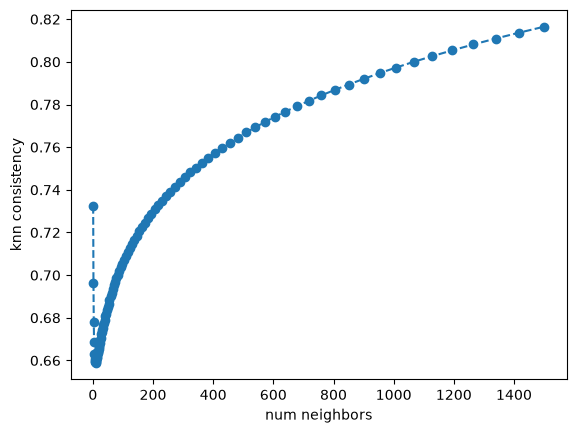

In [20]:
plt.plot(k_range, knn_curve, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn consistency')
plt.show()

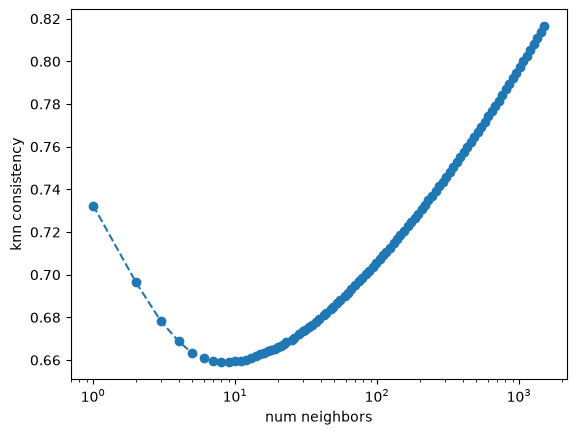

In [21]:
plt.plot(k_range, knn_curve, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn consistency')
plt.xscale('log')
plt.show()

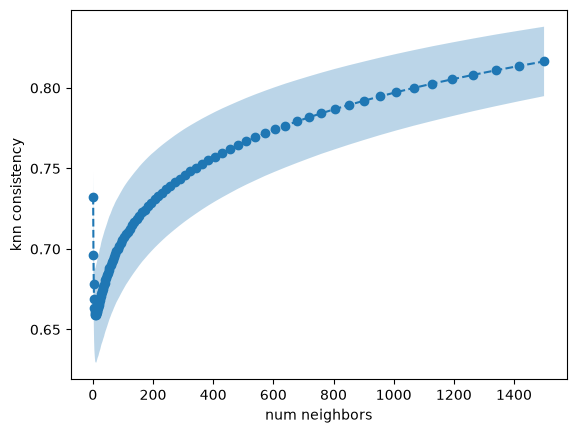

In [22]:
curve_mean = knn_curve

plt.plot(k_range, curve_mean, ls='--', marker='o')
plt.fill_between(
    k_range,
    curve_mean - curve_std,
    curve_mean + curve_std,
    alpha=0.3,
)

plt.xlabel("num neighbors")
plt.ylabel("knn consistency")
plt.show()

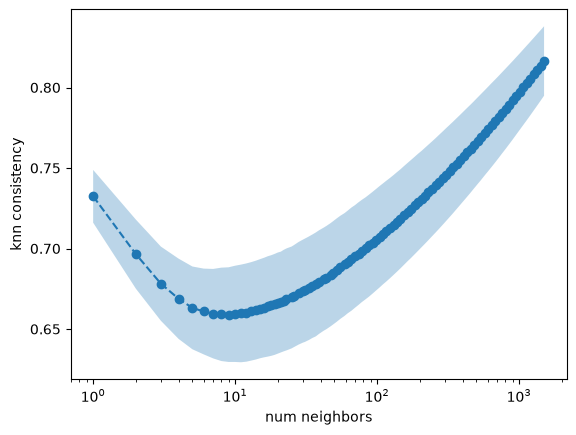

In [23]:
curve_mean = knn_curve

plt.plot(k_range, curve_mean, ls='--', marker='o')
plt.fill_between(
    k_range,
    curve_mean - curve_std,
    curve_mean + curve_std,
    alpha=0.3,
)

plt.xlabel("num neighbors")
plt.ylabel("knn consistency")
plt.xscale('log')
plt.show()

### Clustering and ARI

In [24]:
potential_clusters = np.unique(np.geomspace(2, 150, num=30, dtype=int))

In [25]:
len(unique_embeddings)

3

In [26]:
ari_mean = {}
ari_std = {}
for pc in tqdm(potential_clusters):
    bef_ari = []
    for uq_emb in unique_embeddings:
        km = KMeans(n_clusters=pc,
               init='k-means++',
               n_init='auto',
               max_iter=300,
               tol=0.0001,
               verbose=0,
               random_state=42).fit(uq_emb)
        bef_ari.append(km.labels_)
    scores = []
    for i, j in list(combinations(range(3), 2)):
        scores.append(
            adjusted_rand_score(bef_ari[i], bef_ari[j])
        )

    ari_mean[pc] = np.mean(scores)
    ari_std[pc] = np.std(scores, ddof=1)


100%|██████████| 26/26 [01:49<00:00,  4.20s/it]


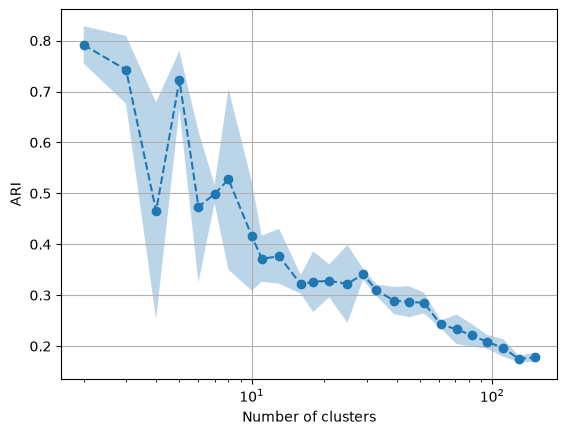

In [27]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o')
plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )

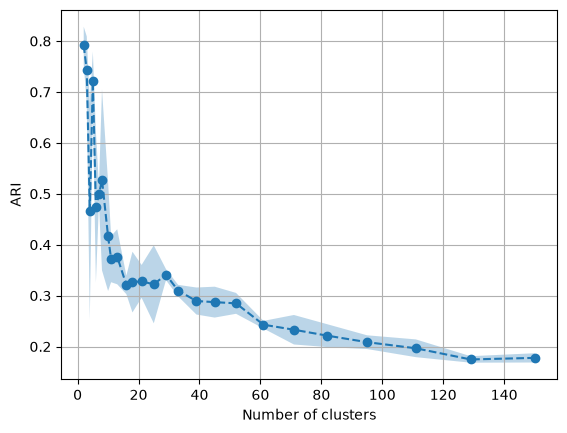

In [28]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o')
plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )

In [29]:
potential_clusters

array([  2,   3,   4,   5,   6,   7,   8,  10,  11,  13,  16,  18,  21,
        25,  29,  33,  39,  45,  52,  61,  71,  82,  95, 111, 129, 150])

In [30]:
ari_mean_2 = {}
ari_std_2 = {}
for pc in tqdm(potential_clusters):
    bef_ari = []
    uq_emb = unique_embeddings[0]
    for s in [42, 101, 569]:
        km = KMeans(n_clusters=pc,
               init='k-means++',
               n_init='auto',
               max_iter=300,
               tol=0.0001,
               verbose=0,
               random_state=s).fit(uq_emb)
        bef_ari.append(km.labels_)
    scores = []
    for i, j in list(combinations(range(3), 2)):
        scores.append(
            adjusted_rand_score(bef_ari[i], bef_ari[j])
        )

    ari_mean_2[pc] = np.mean(scores)
    ari_std_2[pc] = np.std(scores, ddof=1)


100%|██████████| 26/26 [01:42<00:00,  3.95s/it]


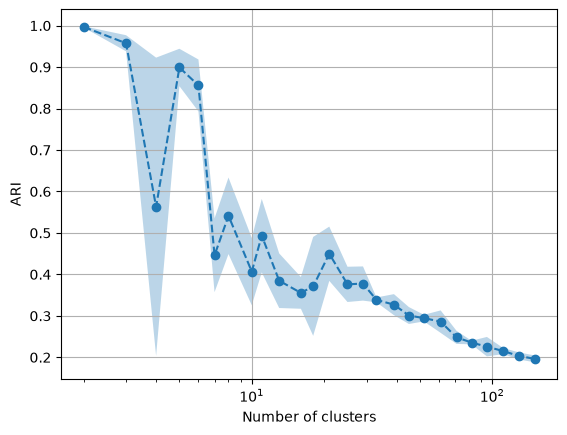

In [31]:
plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o')
plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
                 np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
                 alpha=0.3
                )

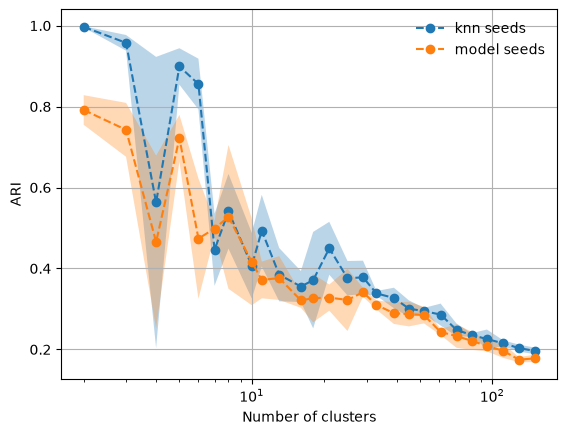

In [32]:
plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
                 np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
                 alpha=0.3
                )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)

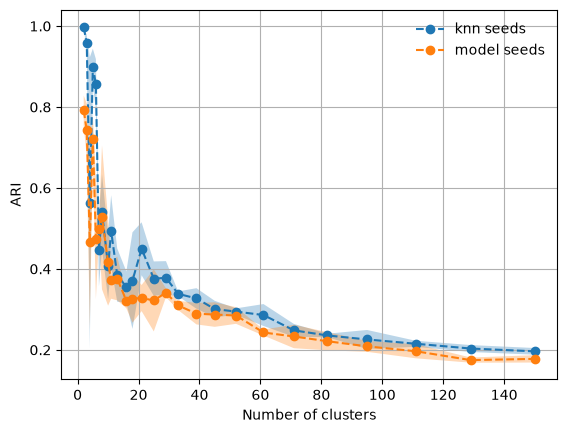

In [33]:
plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
                 np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
                 alpha=0.3
                )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)

### Now try same with spherical GMMs?

In [34]:
from sklearn.mixture import GaussianMixture

In [35]:
ari_mean_gmm = {}
ari_std_gmm = {}
for pc in tqdm(potential_clusters):
    bef_ari = []
    for uq_emb in unique_embeddings:
        bef_ari.append(GaussianMixture(
#             {‘full’, ‘tied’, ‘diag’, ‘spherical’},
            n_components=pc, covariance_type='spherical', random_state=42,
            tol=0.001, reg_covar=1e-05, max_iter=100, n_init=1, init_params='k-means++'
        ).fit_predict(uq_emb))
    scores = []
    for i, j in list(combinations(range(3), 2)):
        scores.append(
            adjusted_rand_score(bef_ari[i], bef_ari[j])
        )

    ari_mean_gmm[pc] = np.mean(scores)
    ari_std_gmm[pc] = np.std(scores, ddof=1)


 96%|█████████▌| 25/26 [09:34<00:36, 36.42s/it]/user/turishcheva/nathans_code/sensorium/.venv/lib/python3.12/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
100%|██████████| 26/26 [10:29<00:00, 24.22s/it]


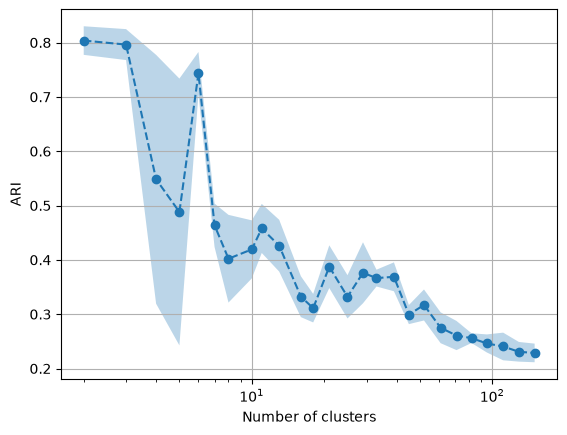

In [36]:
plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o')
plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

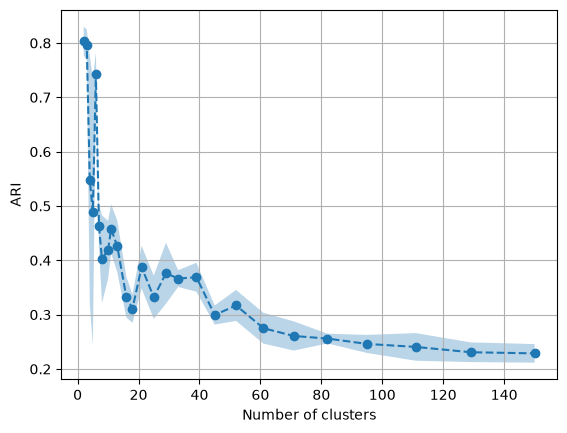

In [37]:
plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o')
plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

### GMM seeds control

In [38]:
ari_mean_2_gmm = {}
ari_std_2_gmm = {}
for pc in tqdm(potential_clusters):
    bef_ari = []
    uq_emb = unique_embeddings[0]
    for s in [42, 101, 569]:
        bef_ari.append(
            GaussianMixture(
#             {'full', 'tied', 'diag', 'spherical'},
            n_components=pc, covariance_type='spherical', random_state=s,
            tol=0.001, reg_covar=1e-05, max_iter=100, n_init=1, init_params='k-means++'
        ).fit_predict(uq_emb)
        )
    scores = []
    for i, j in list(combinations(range(3), 2)):
        scores.append(
            adjusted_rand_score(bef_ari[i], bef_ari[j])
        )

    ari_mean_2_gmm[pc] = np.mean(scores)
    ari_std_2_gmm[pc] = np.std(scores, ddof=1)


 96%|█████████▌| 25/26 [15:52<00:35, 35.43s/it]/user/turishcheva/nathans_code/sensorium/.venv/lib/python3.12/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
100%|██████████| 26/26 [16:47<00:00, 38.76s/it]


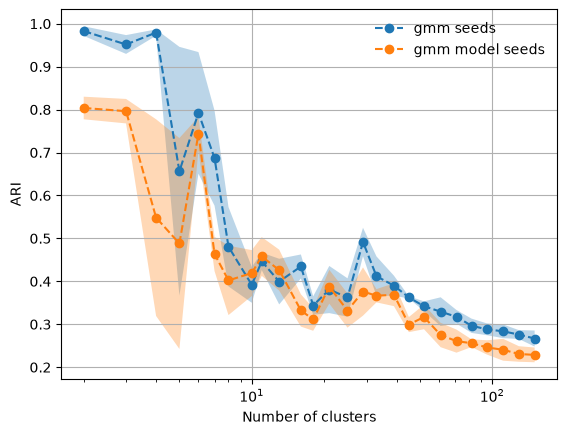

In [39]:
plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
                 np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
                 alpha=0.3
                )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)

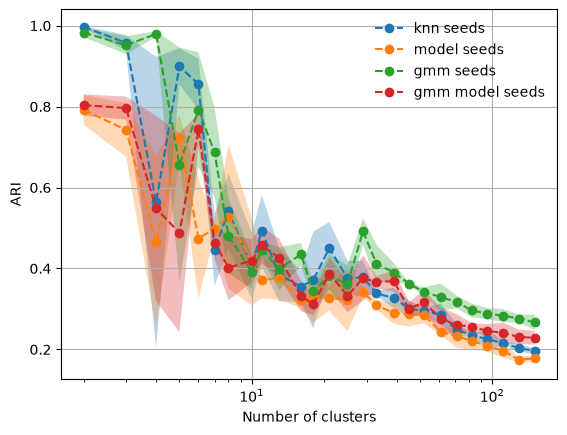

In [40]:
plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
                 np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
                 alpha=0.3
                )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------


plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
                 np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
                 alpha=0.3
                )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)

In [41]:
X = unique_embeddings[0]
mu, C = X.mean(0), np.cov(X.T)
L = np.linalg.cholesky(C + 1e-6*np.eye(X.shape[1]))
G  = mu + np.random.default_rng(0).standard_normal(X.shape)   @ L.T
# gauss_kmeans_12mice = ari_curve([G]*5, [0, 42, 123, 246, 369])

ari_mean_gmm_control = {}
ari_std_gmm_control = {}
for pc in tqdm(potential_clusters):
    bef_ari = []
    uq_emb = G
    for s in [42, 101, 569]:
        bef_ari.append(
            GaussianMixture(
#             {'full', 'tied', 'diag', 'spherical'},
            n_components=pc, covariance_type='spherical', random_state=s,
            tol=0.001, reg_covar=1e-05, max_iter=100, n_init=1, init_params='k-means++'
        ).fit_predict(uq_emb)
        )
    scores = []
    for i, j in list(combinations(range(3), 2)):
        scores.append(
            adjusted_rand_score(bef_ari[i], bef_ari[j])
        )

    ari_mean_gmm_control[pc] = np.mean(scores)
    ari_std_gmm_control[pc] = np.std(scores, ddof=1)


  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [09:15<00:00, 21.38s/it]


In [42]:
aris_dict = {}
aris_dict['ari_mean_2'] = ari_mean_2
aris_dict['ari_mean'] = ari_mean
aris_dict['ari_mean_2_gmm'] = ari_mean_2_gmm
aris_dict['ari_mean_gmm'] = ari_mean_gmm
aris_dict['ari_mean_gmm_control'] = ari_mean_gmm_control


aris_dict['ari_std_2'] = ari_std_2
aris_dict['ari_std'] = ari_std
aris_dict['ari_std_2_gmm'] = ari_std_2_gmm
aris_dict['ari_std_gmm'] = ari_std_gmm
aris_dict['ari_std_gmm_control'] = ari_std_gmm_control


In [43]:
# with open("aris_dict_concavity_w5000_sanity_check.pkl", "wb") as f:
#     pickle.dump(aris_dict, f)

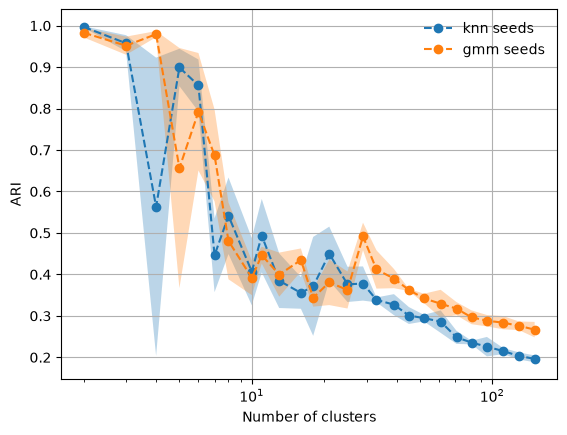

In [44]:
plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
                 np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
                 alpha=0.3
                )


# plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
#                  np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
#                  alpha=0.3
#                 )
# -------


plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
                 np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
                 alpha=0.3
                )


# plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
#                  np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
#                  alpha=0.3
#                 )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)

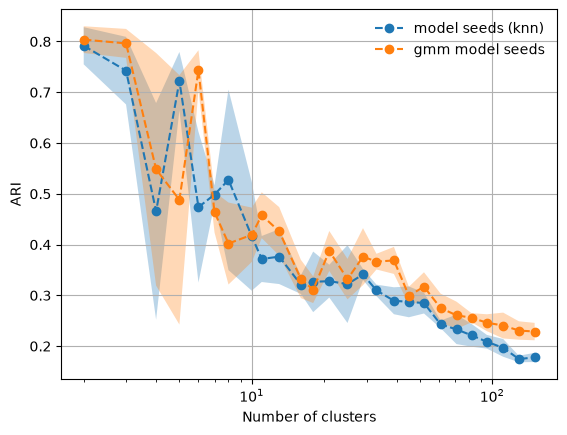

In [45]:
# plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
#                  np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------


# plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
#                  np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)

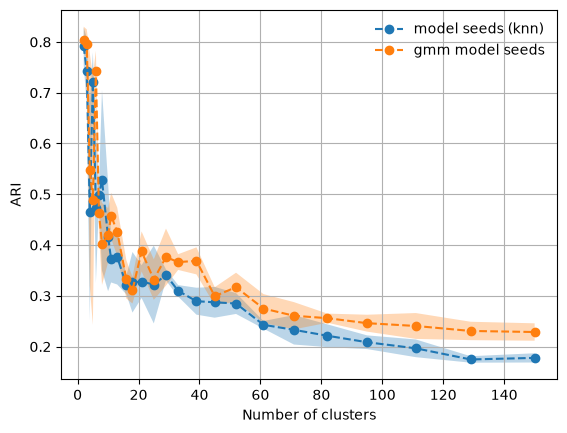

In [46]:
# plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
#                  np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------


# plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
#                  np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)

(2.0, 60.0)

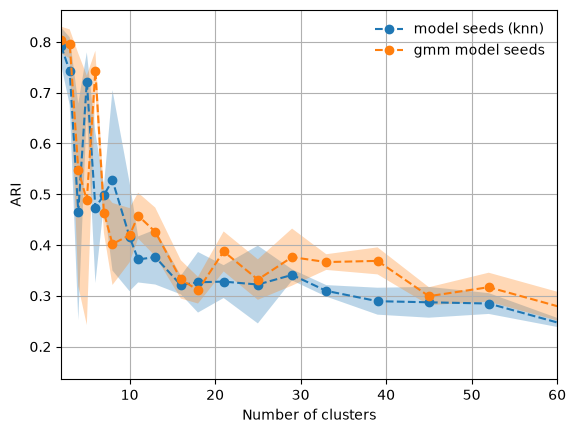

In [47]:
# plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
#                  np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------


# plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
#                  np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)
plt.xlim(2, 60)

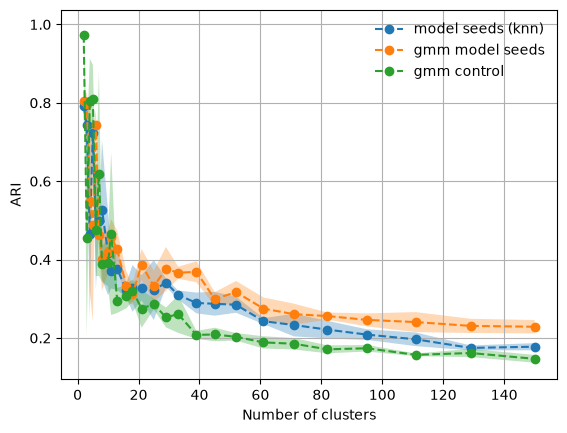

In [48]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------



plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

plt.plot(potential_clusters, list(ari_mean_gmm_control.values()), ls='--', marker='o', label='gmm control')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm_control.values())) - np.asarray(list(ari_std_gmm_control.values())),
                 np.asarray(list(ari_mean_gmm_control.values())) + np.asarray(list(ari_std_gmm_control.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)
# plt.xlim(2, 60)

(2.0, 60.0)

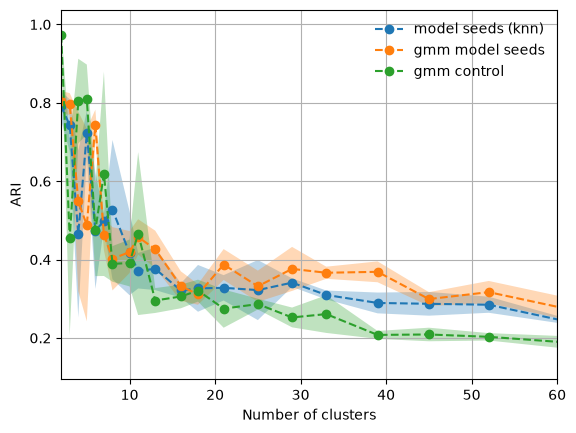

In [49]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------



plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

plt.plot(potential_clusters, list(ari_mean_gmm_control.values()), ls='--', marker='o', label='gmm control')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm_control.values())) - np.asarray(list(ari_std_gmm_control.values())),
                 np.asarray(list(ari_mean_gmm_control.values())) + np.asarray(list(ari_std_gmm_control.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)
plt.xlim(2, 60)

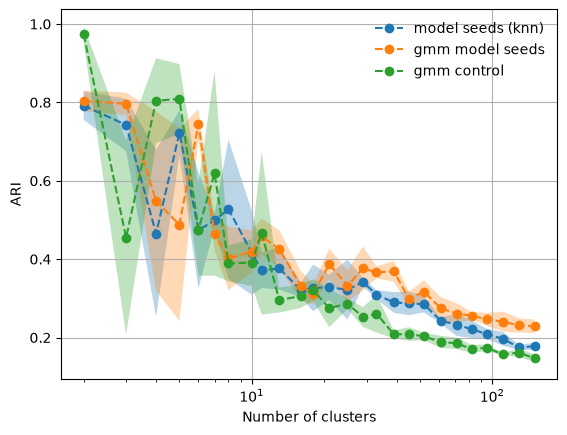

In [50]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------



plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

plt.plot(potential_clusters, list(ari_mean_gmm_control.values()), ls='--', marker='o', label='gmm control')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm_control.values())) - np.asarray(list(ari_std_gmm_control.values())),
                 np.asarray(list(ari_mean_gmm_control.values())) + np.asarray(list(ari_std_gmm_control.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.legend(frameon=False)
# plt.xlim(2, 60)

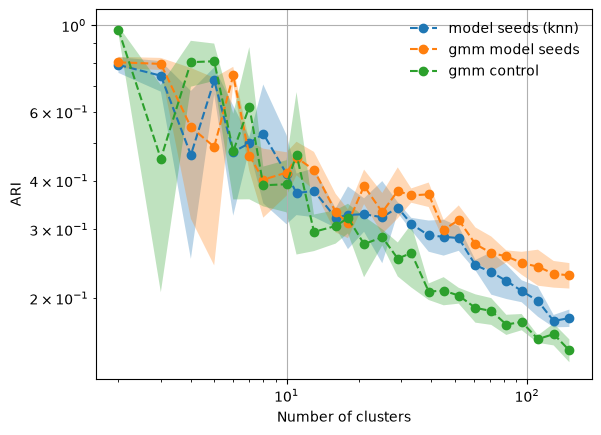

In [51]:
plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------



plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )

plt.plot(potential_clusters, list(ari_mean_gmm_control.values()), ls='--', marker='o', label='gmm control')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm_control.values())) - np.asarray(list(ari_std_gmm_control.values())),
                 np.asarray(list(ari_mean_gmm_control.values())) + np.asarray(list(ari_std_gmm_control.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
plt.xscale('log')
plt.yscale('log')
plt.legend(frameon=False)
# plt.xlim(2, 60)

(0.15, 0.85)

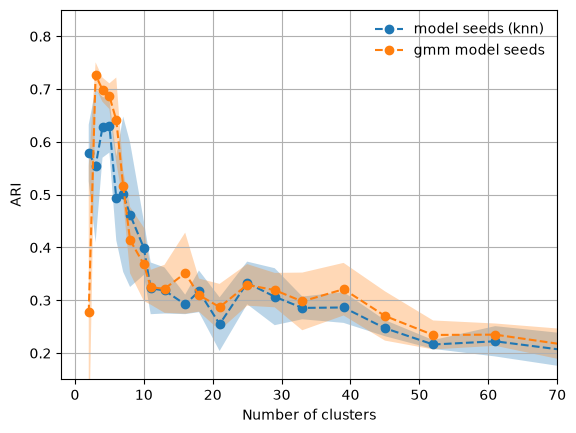

In [51]:
# plt.plot(potential_clusters, list(ari_mean_2.values()), ls='--', marker='o', label='knn seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2.values())) - np.asarray(list(ari_std_2.values())),
#                  np.asarray(list(ari_mean_2.values())) + np.asarray(list(ari_std_2.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean.values()), ls='--', marker='o', label='model seeds (knn)')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean.values())) - np.asarray(list(ari_std.values())),
                 np.asarray(list(ari_mean.values())) + np.asarray(list(ari_std.values())),
                 alpha=0.3
                )
# -------


# plt.plot(potential_clusters, list(ari_mean_2_gmm.values()), ls='--', marker='o', label='gmm seeds')
# plt.fill_between(potential_clusters,
#                  np.asarray(list(ari_mean_2_gmm.values())) - np.asarray(list(ari_std_2_gmm.values())),
#                  np.asarray(list(ari_mean_2_gmm.values())) + np.asarray(list(ari_std_2_gmm.values())),
#                  alpha=0.3
#                 )


plt.plot(potential_clusters, list(ari_mean_gmm.values()), ls='--', marker='o', label='gmm model seeds')
plt.fill_between(potential_clusters,
                 np.asarray(list(ari_mean_gmm.values())) - np.asarray(list(ari_std_gmm.values())),
                 np.asarray(list(ari_mean_gmm.values())) + np.asarray(list(ari_std_gmm.values())),
                 alpha=0.3
                )


plt.grid()
plt.ylabel('ARI')
plt.xlabel('Number of clusters')
# plt.xscale('log')
plt.legend(frameon=False)
plt.xlim(-2, 70)
plt.ylim(0.15, 0.85)